In [ ]:
import numpy as np
import pandas as pd

np.random.seed(42)
rows = 5000

# -------------------------
# Feature Generation
# -------------------------
data = pd.DataFrame({
    "project_id": np.arange(1, rows+1),
    "project_size_m2": np.random.normal(10000, 3000, rows).clip(2000, 25000),
    "duration_days": np.random.normal(600, 180, rows).clip(150, 1500),
    "material_cost_index": np.random.normal(100, 20, rows).clip(60, 200),
    "weather_delay_days": np.random.poisson(6, rows),
    "design_changes_count": np.random.poisson(3, rows),
    "contractor_experience_years": np.random.randint(1, 35, rows),
    "accidents_count": np.random.poisson(1, rows),
    "crew_size": np.random.randint(20, 500, rows),
    "equipment_count": np.random.randint(5, 100, rows),
    "material_type": np.random.randint(0, 5, rows),
    "material_trend": np.random.randint(0, 3, rows),
})

# -------------------------
# Derived + Interaction Features
# -------------------------

# Efficiency score - larger and longer projects should scale efficiency differently
data["productivity_ratio"] = (data["crew_size"] * 0.6 + data["equipment_count"] * 0.4) / data["duration_days"]

# Cost pressure score (material inflation + delays + accidents)
data["cost_risk_factor"] = (
    (data["material_cost_index"] - 100).clip(0) * 0.02 +
    data["weather_delay_days"] * 0.04 +
    data["accidents_count"] * 0.08
)

# Experience effect: more experience = lower risk
data["experience_modifier"] = np.where(
    data["contractor_experience_years"] < 5, 0.25,
    np.where(data["contractor_experience_years"] < 15, 0.15, -0.05)
)

# Scope creep probability from design changes
data["scope_creep_score"] = np.where(
    data["design_changes_count"] >= 5, 0.35,
    data["design_changes_count"] * 0.05
)

# -------------------------
# Probability Model for Overrun
# -------------------------

baseline_risk = (
    0.20 * data["scope_creep_score"] +
    0.25 * data["cost_risk_factor"] +
    0.20 * data["experience_modifier"] +
    0.18 * (data["material_trend"] == 0).astype(int) * 0.15 +  # Trend = Rising
    0.10 * (data["project_size_m2"] > 15000).astype(int) +
    np.random.normal(0, 0.05, rows)
)

# Convert to probability range 0–1
risk_prob = 1 / (1 + np.exp(-baseline_risk))

# -------------------------
# Classification Label
# -------------------------

# 40% Overrun target distribution
threshold = np.quantile(risk_prob, 0.60)
overrun_flag = (risk_prob > threshold).astype(int)
data["overrun_flag"] = overrun_flag

# -------------------------
# Continuous Cost Overrun %
# -------------------------
data["cost_overrun_percentage"] = np.where(
    overrun_flag == 1,
    np.round((risk_prob * np.random.uniform(8, 28)) + data["design_changes_count"] * 0.8, 2),
    np.round(np.abs(np.random.normal(0, 4, rows)), 2)
)

# -------------------------
# Save Output
# -------------------------
data.to_csv("realistic_construction_dataset.csv", index=False)

print("New improved dataset created: realistic_construction_dataset.csv")
print(data.head())
print("\nClass distribution:\n", data["overrun_flag"].value_counts())


New improved dataset created: realistic_construction_dataset.csv
   project_id  project_size_m2  duration_days  material_cost_index  \
0           1     11490.142459     523.723257            86.430105   
1           2      9585.207096     518.385460            93.890011   
2           3     11943.065614     276.784229            88.052379   
3           4     14569.089569     540.583765           102.208361   
4           5      9297.539876     731.909235           123.943571   

   weather_delay_days  design_changes_count  contractor_experience_years  \
0                   4                     1                           30   
1                   3                     2                           10   
2                   4                     4                           31   
3                   6                     2                           26   
4                   3                     6                           30   

   accidents_count  crew_size  equipment_count  material_

📁 Dataset saved: realistic_construction_dataset.csv
    budget  duration_planned  material_cost_index  weather_delay_days  \
0  4404020                22             1.102440                  11   
1  3008768                13             0.775638                  10   
2  4821584                44             1.490807                   6   
3  8152359                37             1.074093                   9   
4  2840549                21             1.027778                   6   

   labor_skill_rating  site_access_rating  project_complexity_rating  \
0                   5                   4                          3   
1                   4                   1                          2   
2                   4                   4                          3   
3                   3                   2                          5   
4                   4                   3                          1   

   contract_type  trend  overrun_flag  
0              1      0             

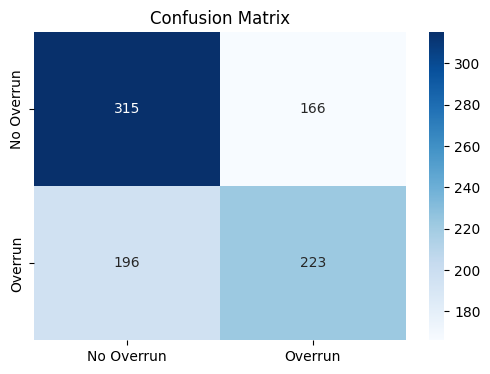


🏆 Feature Importance Ranking:

                     Feature  Importance
0                     budget    0.206002
2        material_cost_index    0.203165
1           duration_planned    0.152489
3         weather_delay_days    0.131590
6  project_complexity_rating    0.084624
5         site_access_rating    0.073334
4         labor_skill_rating    0.069791
8                      trend    0.047412
7              contract_type    0.031593


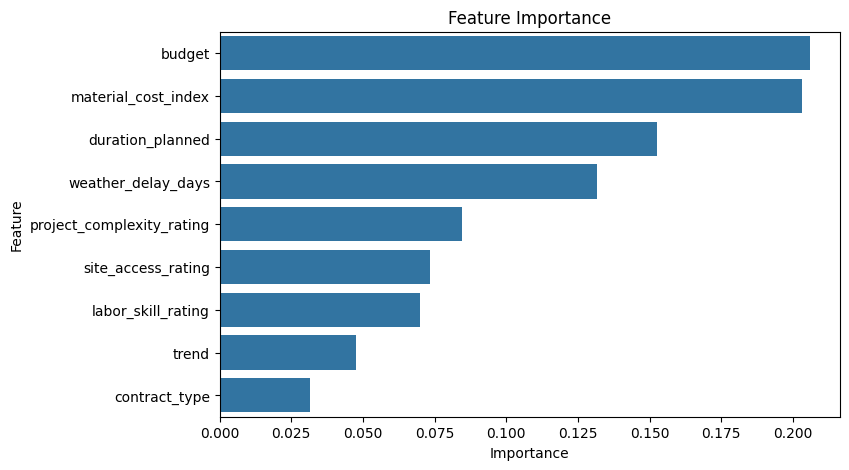

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(42)

# ----------------------------
# 1) GENERATE REALISTIC DATASET
# ----------------------------

n = 3000  # dataset size

# Base numeric fields with realistic relationships
budget = np.random.lognormal(mean=15, sigma=0.6, size=n).astype(int)  # skewed distribution
duration_planned = (budget / np.random.uniform(7e4, 2.2e5, n)).astype(int)

duration_planned = np.clip(duration_planned, 6, 60)

material_cost_index = np.random.normal(1.15, 0.25, n)
material_cost_index = np.clip(material_cost_index, 0.7, 2.2)

weather_delay_days = np.random.poisson(10, n)
labor_skill_rating = np.random.choice([1,2,3,4,5], p=[0.1,0.2,0.35,0.25,0.1], size=n)
site_access_rating = np.random.randint(1, 6, n)
project_complexity_rating = np.random.choice([1,2,3,4,5], p=[0.05, 0.15, 0.30, 0.30, 0.20], size=n)

contract_type = np.random.choice([0, 1], size=n, p=[0.6, 0.4])  # fixed-price more common

trend = np.random.choice([-1, 0, 1], size=n, p=[0.2, 0.5, 0.3])  # stable more common

# ----------------------------
# 2) CALCULATE PROBABILITY OF OVERRUN (Non-linear model)
# ----------------------------

base_risk = (
    0.25 * project_complexity_rating +
    0.22 * material_cost_index +
    0.16 * trend +
    0.18 * contract_type +
    0.02 * weather_delay_days -
    0.12 * labor_skill_rating -
    0.07 * site_access_rating
)

# Add interactions — real-world effect multipliers
interaction_term = (
    0.15 * (weather_delay_days * (project_complexity_rating / 5)) +
    0.20 * (material_cost_index * (trend > 0)) +
    0.25 * (contract_type * (material_cost_index > 1.3))
)

# Introduce noise (random unforeseeable conditions)
noise = np.random.normal(0, 0.4, n)

risk_score = base_risk + interaction_term + noise

# Normalize risk score 0-1
p = (risk_score - risk_score.min()) / (risk_score.max() - risk_score.min())

# Generate final label
overrun_flag = (np.random.rand(n) < p).astype(int)

# ----------------------------
# 3) CREATE DATAFRAME & SAVE
# ----------------------------

df = pd.DataFrame({
    "budget": budget,
    "duration_planned": duration_planned,
    "material_cost_index": material_cost_index,
    "weather_delay_days": weather_delay_days,
    "labor_skill_rating": labor_skill_rating,
    "site_access_rating": site_access_rating,
    "project_complexity_rating": project_complexity_rating,
    "contract_type": contract_type,
    "trend": trend,
    "overrun_flag": overrun_flag
})

df.to_csv("realistic_construction_dataset.csv", index=False)
print("📁 Dataset saved: realistic_construction_dataset.csv")
print(df.head())


# ----------------------------
# 4) MODEL TRAINING
# ----------------------------

X = df.drop(columns=["overrun_flag"])
y = df["overrun_flag"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

model = RandomForestClassifier(n_estimators=250, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\n📊 Classification Report:\n")
print(classification_report(y_test, y_pred))

print("🎯 Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")


# ----------------------------
# 5) CONFUSION MATRIX VISUALIZATION
# ----------------------------

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
            xticklabels=["No Overrun", "Overrun"],
            yticklabels=["No Overrun", "Overrun"])
plt.title("Confusion Matrix")
plt.show()


# ----------------------------
# 6) FEATURE IMPORTANCE
# ----------------------------

importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\n🏆 Feature Importance Ranking:\n")
print(importances)

plt.figure(figsize=(8,5))
sns.barplot(x="Importance", y="Feature", data=importances)
plt.title("Feature Importance")
plt.show()


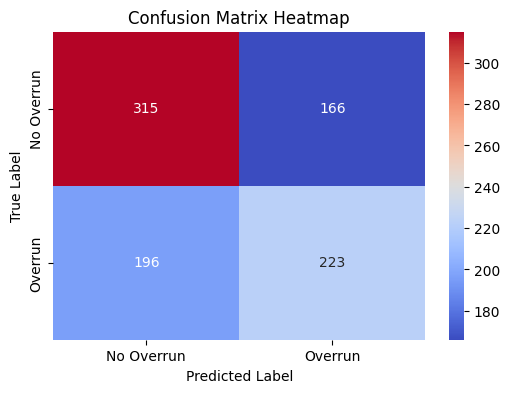


📌 Detailed Metrics Table:



,Class,Precision,Recall,F1-score,Support
0,No Overrun (0),0.616438,0.654886,0.635081,481
1,Overrun (1),0.573265,0.532220,0.551980,419



📊 Full Classification Report:

              precision    recall  f1-score   support

           0       0.62      0.65      0.64       481
           1       0.57      0.53      0.55       419

    accuracy                           0.60       900
   macro avg       0.59      0.59      0.59       900
weighted avg       0.60      0.60      0.60       900



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# -------------------------
# CONFUSION MATRIX + HEATMAP
# -------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm",
            xticklabels=["No Overrun", "Overrun"],
            yticklabels=["No Overrun", "Overrun"])
plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# -------------------------
# Precision / Recall / F1
# -------------------------
precision, recall, f1, support = precision_recall_fscore_support(y_test, y_pred)

metrics_df = pd.DataFrame({
    "Class": ["No Overrun (0)", "Overrun (1)"],
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1,
    "Support": support
})

print("\n📌 Detailed Metrics Table:\n")
display(metrics_df)

print("\n📊 Full Classification Report:\n")
print(classification_report(y_test, y_pred))



In [ ]:
print("Dataset size:", len(df))
print("Train size:", len(X_train))
print("Test size:", len(X_test))


Dataset size: 3000
Train size: 2100
Test size: 900


In [ ]:
import joblib

joblib.dump(model, "construction_overrun_model.joblib")
print("✅ Model saved in project root folder!")



✅ Model saved in project root folder!


SHAP raw type: <class 'numpy.ndarray'>
Detected 3D matrix → extracting positive class (index=1)
Final SHAP matrix shape: (900, 9)


/tmp/ipython-input-3832557224.py:20: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_plot, X_test, plot_size=(10,6))


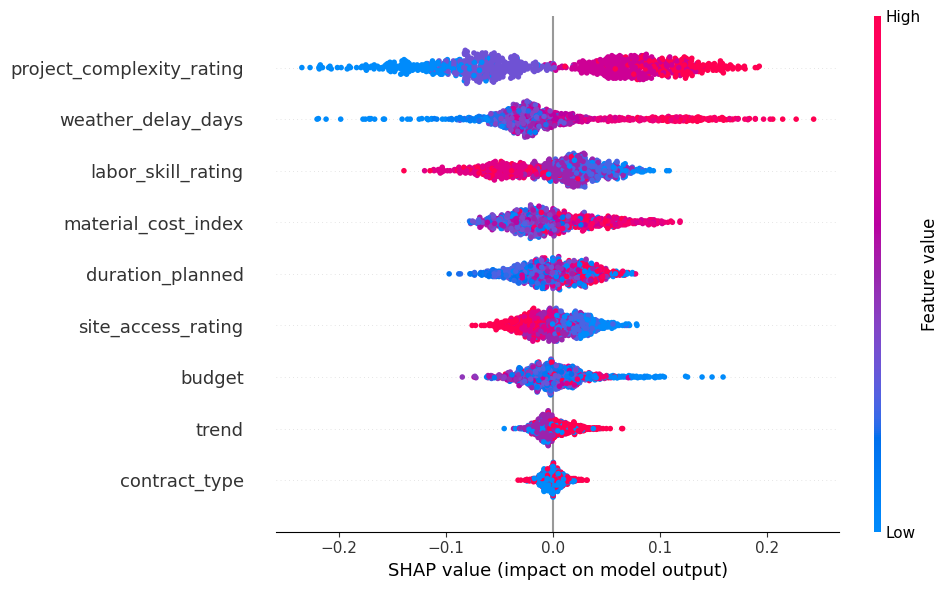

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

print("SHAP raw type:", type(shap_values))

if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    print("Detected 3D matrix → extracting positive class (index=1)")
    shap_values_plot = shap_values[:, :, 1]
else:
    print("Detected list format → extracting index=1")
    shap_values_plot = shap_values[1]

print("Final SHAP matrix shape:", shap_values_plot.shape)

shap.summary_plot(shap_values_plot, X_test, plot_size=(10,6))


In [ ]:
import numpy as np

def predict_overrun(
    budget,
    duration_planned,
    material_cost_index,
    weather_delay_days,
    labor_skill_rating,
    site_access_rating,
    project_complexity_rating,
    contract_type,
    trend
):
    """
    Predict cost overrun likelihood using trained model.
    """

    # format input as dataframe
    input_data = pd.DataFrame([{
        "budget": budget,
        "duration_planned": duration_planned,
        "material_cost_index": material_cost_index,
        "weather_delay_days": weather_delay_days,
        "labor_skill_rating": labor_skill_rating,
        "site_access_rating": site_access_rating,
        "project_complexity_rating": project_complexity_rating,
        "contract_type": contract_type,
        "trend": trend
    }])

    # prediction
    prediction = model.predict(input_data)[0]
    probability = model.predict_proba(input_data)[0][1]

    return {
        "prediction": "Overrun" if prediction == 1 else "No Overrun",
        "overrun_probability": round(probability * 100, 2)
    }



test = predict_overrun(
    budget=1_200_000,
    duration_planned=12,
    material_cost_index=1.4,
    weather_delay_days=14,
    labor_skill_rating=2,
    site_access_rating=3,
    project_complexity_rating=5,
    contract_type=1,
    trend=1
)

print("\n🔍 Prediction Result:", test)



🔍 Prediction Result: {'prediction': 'Overrun', 'overrun_probability': np.float64(71.6)}


In [ ]:
import joblib

joblib.dump(model, "best_overrun_model.joblib")
joblib.dump(X_train.columns.tolist(), "model_columns.joblib")

print("Model & column structure saved successfully.")


Model & column structure saved successfully.


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib
import numpy as np

# --------------------------
# 1) Load Model
# --------------------------
MODEL_PATH = "construction_overrun_model.joblib"

try:
    model = joblib.load(MODEL_PATH)
    st.success("✅ Model Loaded Successfully!")
except:
    st.error("❌ Model file not found! Please make sure 'construction_overrun_model.joblib' exists.")
    st.stop()


# --------------------------
# 2) App UI Design
# --------------------------
st.title("🏗️ AI Construction Cost Overrun Predictor")

st.write("""
This tool predicts the likelihood of a **construction project exceeding budget or time**
based on realistic risk factors.
""")

st.divider()

# --------------------------
# 3) User Input Controls
# --------------------------
col1, col2 = st.columns(2)

with col1:
    budget = st.number_input("💰 Project Budget ($)", min_value=50000, max_value=20000000, value=5000000, step=50000)
    duration_planned = st.slider("📅 Planned Duration (months)", 1, 60, 24)
    material_cost_index = st.slider("📦 Material Cost Index", 0.7, 2.2, 1.15, step=0.01)
    weather_delay_days = st.slider("⛈️ Weather Delay (days)", 0, 60, 10)

with col2:
    labor_skill_rating = st.selectbox("👷 Labor Skill Level", [1,2,3,4,5])
    site_access_rating = st.selectbox("🚧 Site Accessibility Rating", [1,2,3,4,5])
    project_complexity_rating = st.selectbox("🏗 Project Complexity", [1,2,3,4,5])
    contract_type = st.selectbox("📄 Contract Type", ["Lump Sum (0)", "Cost Plus (1)"])
    trend = st.selectbox("📈 Market Trend", ["Declining (-1)", "Stable (0)", "Rising (1)"])


# Convert encoded fields
contract_type_val = 1 if "Cost Plus" in contract_type else 0
trend_val = -1 if "Declining" in trend else 1 if "Rising" in trend else 0

# --------------------------
# 4) DataFrame for Prediction
# --------------------------
input_data = pd.DataFrame([{
    "budget": budget,
    "duration_planned": duration_planned,
    "material_cost_index": material_cost_index,
    "weather_delay_days": weather_delay_days,
    "labor_skill_rating": labor_skill_rating,
    "site_access_rating": site_access_rating,
    "project_complexity_rating": project_complexity_rating,
    "contract_type": contract_type_val,
    "trend": trend_val
}])

# --------------------------
# 5) Prediction Button
# --------------------------
if st.button("🔍 Predict Overrun Risk"):
    prediction = model.predict(input_data)[0]
    probability = model.predict_proba(input_data)[0][1] * 100

    if prediction == 1:
        st.error(f"🚨 High Risk of Overrun\n📌 Probability: **{probability:.2f}%**")
    else:
        st.success(f"🟢 Low Risk of Overrun\n📌 Probability: **{probability:.2f}%**")

    st.subheader("📊 Model Input Summary")
    st.dataframe(input_data)


st.divider()
st.caption("🔧 Powered by Machine Learning + Streamlit")


Overwriting app.py


In [ ]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 53.5 MB/s eta 0:00:00


In [ ]:
from pyngrok import ngrok
ngrok.set_auth_token("35WhUci9RFkOw28arbKmNgqg6ps_4FkHYJfmTCykUHqCfpK82")
ngrok.kill()

url = ngrok.connect(8501)
print("📍 Public URL:", url)

ERROR:pyngrok.process.ngrok:t=2025-11-21T21:34:02+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: Your account is limited to 3 simultaneous ngrok agent sessions.\nRun multiple endpoints at the same time from a single agent by defining them in your agent configuration file and running `ngrok start --all`.\nRead more about the agent configuration file: https://ngrok.com/docs/agent/config/ \nYou can view your current agent sessions in the dashboard: https://dashboard.ngrok.com/agents. Upgrade to a paid plan to remove this limit:\nhttps://dashboard.ngrok.com/billing/choose-a-plan\r\n\r\nERR_NGROK_108\r\n"
ERROR:pyngrok.process.ngrok:t=2025-11-21T21:34:02+0000 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: Your account is limited to 3 simultaneous ngrok agent sessions.\nRun multiple endpoints at the same time from a single agent by defining them in your agent configuration file and running `ngrok start --all`.\n

PyngrokNgrokError: The ngrok process errored on start: authentication failed: Your account is limited to 3 simultaneous ngrok agent sessions.\nRun multiple endpoints at the same time from a single agent by defining them in your agent configuration file and running `ngrok start --all`.\nRead more about the agent configuration file: https://ngrok.com/docs/agent/config/ \nYou can view your current agent sessions in the dashboard: https://dashboard.ngrok.com/agents. Upgrade to a paid plan to remove this limit:\nhttps://dashboard.ngrok.com/billing/choose-a-plan\r\n\r\nERR_NGROK_108\r\n.